# **ResNet50V2**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile

zip_path = '/content/drive/My Drive/90-10 split dataset and models/Dataset.zip'
extract_to = '/content/Dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ Dataset extracted to /content/Dataset")

✅ Dataset extracted to /content/Dataset


# **Controlled Environment**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/Dataset/Controlled Environment/Train"
test_dir = "/content/Dataset/Controlled Environment/Test"

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.1)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 725 images belonging to 3 classes.
Found 78 images belonging to 3 classes.
Found 90 images belonging to 3 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=32
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 206s 9s/step - accuracy: 0.7061 - loss: 0.7407 - val_accuracy: 0.8718 - val_loss: 0.3665
Epoch 2/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 172s 7s/step - accuracy: 0.9547 - loss: 0.1047 - val_accuracy: 0.8974 - val_loss: 0.2665
Epoch 3/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 204s 7s/step - accuracy: 0.9865 - loss: 0.0488 - val_accuracy: 0.9231 - val_loss: 0.2054
Epoch 4/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 172s 7s/step - accuracy: 0.9922 - loss: 0.0307 - val_accuracy: 0.9231 - val_loss: 0.2276
Epoch 5/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 179s 8s/step - accuracy: 0.9949 - loss: 0.0227 - val_accuracy: 0.9103 - val_loss: 0.2228
Epoch 6/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 182s 8s/step - accuracy: 0.9989 - loss: 0.0185 - val_accuracy: 0.9231 - val_loss: 0.2180
Epoch 7/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 177s 8s/step - accuracy: 1.0000 - loss: 0.0100 - val_accuracy: 0.9231 - val_loss: 0.2798
Epoch 8/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 177s 8s/step - accuracy: 1.0000 - loss: 0.0134 - val_accuracy: 0.9103 - v

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_true, y_pred) * 100
prec = precision_score(y_true, y_pred, average='weighted') * 100
rec = recall_score(y_true, y_pred, average='weighted') * 100
f1 = f1_score(y_true, y_pred, average='weighted') * 100

print("✅ Evaluation Metrics")
print(f"Accuracy : {acc:f}%")
print(f"Precision: {prec:f}")
print(f"Recall   : {rec:f}")
print(f"F1 Score : {f1:f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 8s/step
✅ Evaluation Metrics
Accuracy : 97.777778%
Precision: 97.901235
Recall   : 97.777778
F1 Score : 97.756614


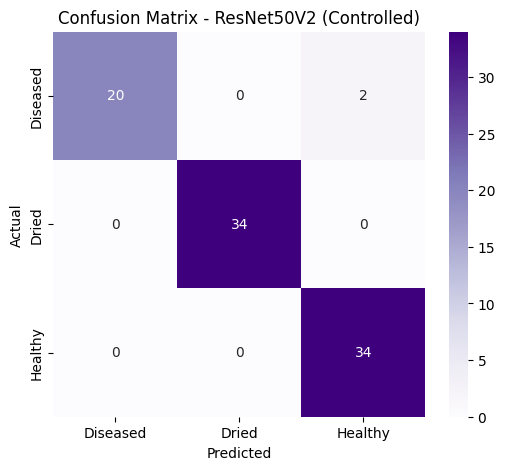

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
class_labels = list(test_gen.class_indices.keys())

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - ResNet50V2 (Controlled)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


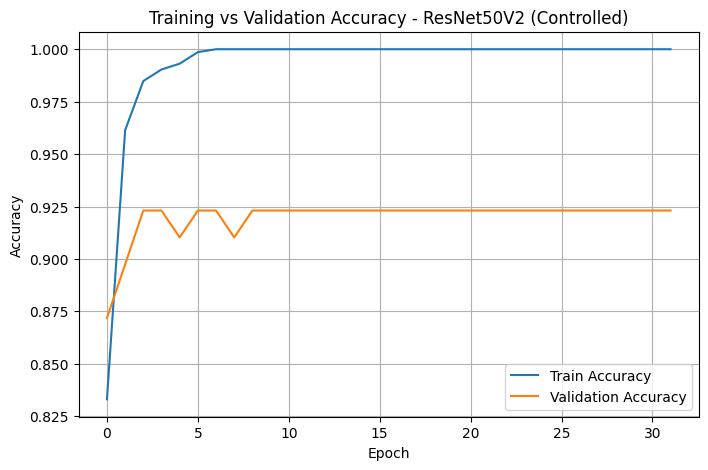

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy - ResNet50V2 (Controlled)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# **On Field**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/Dataset/On Field/Train"
test_dir = "/content/Dataset/On Field/Test"

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.1)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 734 images belonging to 3 classes.
Found 81 images belonging to 3 classes.
Found 92 images belonging to 3 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')  # 3 output classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=32
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 237s 10s/step - accuracy: 0.6762 - loss: 0.8650 - val_accuracy: 0.8395 - val_loss: 0.3480
Epoch 2/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 226s 10s/step - accuracy: 0.9190 - loss: 0.2135 - val_accuracy: 0.8519 - val_loss: 0.3050
Epoch 3/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 235s 9s/step - accuracy: 0.9515 - loss: 0.1346 - val_accuracy: 0.8642 - val_loss: 0.2715
Epoch 4/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 200s 9s/step - accuracy: 0.9850 - loss: 0.0722 - val_accuracy: 0.8765 - val_loss: 0.3259
Epoch 5/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 213s 9s/step - accuracy: 0.9926 - loss: 0.0528 - val_accuracy: 0.8642 - val_loss: 0.2979
Epoch 6/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 190s 8s/step - accuracy: 0.9980 - loss: 0.0329 - val_accuracy: 0.8519 - val_loss: 0.3464
Epoch 7/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 197s 8s/step - accuracy: 0.9975 - loss: 0.0263 - val_accuracy: 0.8519 - val_loss: 0.3542
Epoch 8/32
23/23 ━━━━━━━━━━━━━━━━━━━━ 205s 9s/step - accuracy: 0.9981 - loss: 0.0200 - val_accuracy: 0.8765 -

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_true, y_pred) * 100
prec = precision_score(y_true, y_pred, average='weighted') * 100
rec = recall_score(y_true, y_pred, average='weighted') * 100
f1 = f1_score(y_true, y_pred, average='weighted') * 100

print("✅ Evaluation Metrics")
print(f"Accuracy : {acc:f}%")
print(f"Precision: {prec:f}")
print(f"Recall   : {rec:f}")
print(f"F1 Score : {f1:f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 26s 6s/step
✅ Evaluation Metrics
Accuracy : 84.782609%
Precision: 85.031946
Recall   : 84.782609
F1 Score : 84.844720


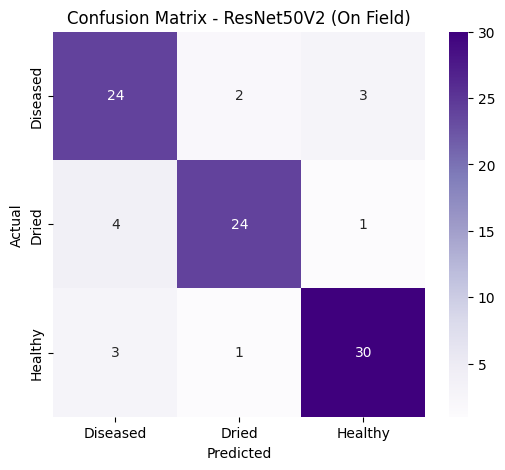

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
class_labels = list(test_gen.class_indices.keys())

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - ResNet50V2 (On Field)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

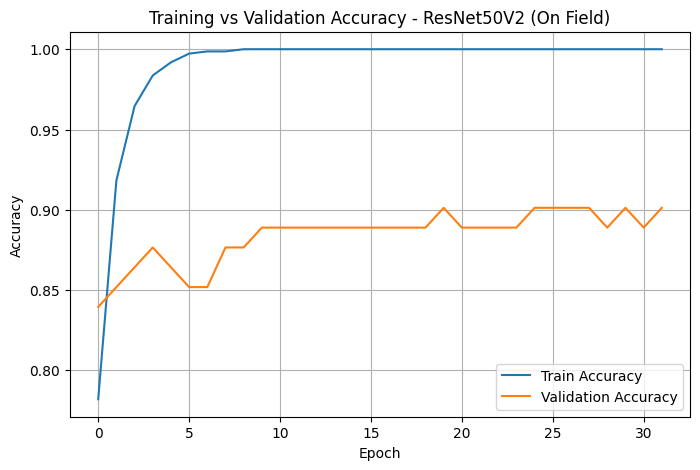

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy - ResNet50V2 (On Field)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.save('/content/drive/MyDrive/90-10 split dataset and models/Trained_Models/ResNet50V2.h5')